# Factors Associated with Heart Disease in a Public Heart Disease Dataset

Author: Hana Aglan  
Institution: George Washington University  
Course: Introduction to Health Data Science PUBH 1142  
Date: 04/27/2026

## Introduction

Heart disease is one of the most significant public health challenges worldwide, affecting millions of individuals and placing a major burden on healthcare systems. In the United States, heart disease is the leading cause of death, accounting for a substantial proportion of mortality across all demographic groups [1]. Globally, cardiovascular diseases are responsible for approximately 17.9 million deaths each year, making them the leading cause of death worldwide [3]. These statistics highlight the importance of understanding heart disease from both a clinical and public health perspective. Identifying risk factors and patterns associated with heart disease is essential for improving prevention strategies, early detection, and patient outcomes.

Existing research has identified several key risk factors associated with heart disease, including age, sex, high blood pressure, high cholesterol, and lifestyle-related factors such as physical inactivity and poor diet [1][3]. Clinical indicators such as chest pain type, exercise-induced angina, maximum heart rate, and electrocardiographic results are also commonly used to assess cardiovascular health. While these factors are well established, there is still a need to better understand how they interact within specific datasets and patient populations. Many studies focus on predictive modeling, but fewer emphasize descriptive analysis that clearly illustrates how these variables differ between patients with and without heart disease. This creates a gap in understanding how observable patterns in real-world data reflect known clinical risk factors.

The objective of this study is to analyze a public heart disease dataset and examine how patient characteristics differ by heart disease status. This study aims to provide a clear, descriptive understanding of how demographic and clinical variables are distributed among patients with and without heart disease. The primary research question is: Which variables appear to be associated with the presence of heart disease in this dataset? It is hypothesized that variables such as age, chest pain type, exercise-induced angina, and maximum heart rate will show noticeable differences between patients with and without heart disease. By addressing this question, the study contributes to a better understanding of how known risk factors are reflected in real patient data.

## Background

Heart disease, also referred to as cardiovascular disease (CVD), includes a range of conditions that affect the heart and blood vessels, such as coronary artery disease, heart failure, and arrhythmias. According to the World Health Organization, cardiovascular diseases are primarily caused by a combination of behavioral and physiological risk factors, including tobacco use, unhealthy diet, lack of physical activity, high blood pressure, high cholesterol, and diabetes [3]. These factors contribute to the development of atherosclerosis, a condition in which arteries become narrowed or blocked, reducing blood flow to the heart. Because many of these risk factors are modifiable, public health efforts often focus on prevention through lifestyle changes and early intervention.

In the United States, the Centers for Disease Control and Prevention reports that heart disease remains the leading cause of death and is responsible for significant healthcare costs and loss of productivity [1]. The CDC emphasizes that high blood pressure, high cholesterol, and smoking are among the most important risk factors, and that nearly half of adults have at least one of these conditions [1]. These findings demonstrate the widespread nature of cardiovascular risk and highlight the importance of identifying patterns that may indicate increased risk of heart disease.

The dataset used in this study originates from the UCI Machine Learning Repository and was compiled by Janosi, Steinbrunn, Pfisterer, and Detrano [2]. It is one of the most widely used datasets in health data science and machine learning for studying heart disease. The dataset includes a combination of demographic, clinical, and diagnostic variables that are commonly used in cardiovascular research. These variables include age, sex, resting blood pressure, cholesterol levels, fasting blood sugar, chest pain type, maximum heart rate, exercise-induced angina, ST depression (oldpeak), slope of the ST segment, number of major vessels, and thalassemia results.

Each of these variables provides insight into different aspects of cardiovascular health. For example, age and sex are important demographic factors, while blood pressure and cholesterol are key clinical indicators of cardiovascular risk. Chest pain type and exercise-induced angina provide information about symptoms experienced by patients, and variables such as ST depression and slope offer insight into heart function during stress testing. The number of major vessels and thalassemia results are more advanced diagnostic indicators that may reflect underlying structural or functional abnormalities in the heart.

While previous research has extensively used this dataset for predictive modeling and classification tasks, this study focuses on descriptive analysis. Descriptive analysis is important because it allows researchers to visually explore patterns and relationships within the data before applying more complex statistical or machine learning techniques. By examining how each variable differs between patients with and without heart disease, this study provides a clearer understanding of how known risk factors appear in real-world data.

Overall, this study is significant because it connects established public health knowledge about heart disease with observed patterns in a widely used dataset. By combining insights from major public health organizations such as the CDC and WHO with empirical data analysis, this research contributes to a more comprehensive understanding of cardiovascular risk factors and their representation in patient-level data.

## Methods

### Study Design, Population, and Data Collection

This project uses a cross-sectional analysis of a public heart disease dataset. Each row represents one patient, and each column represents a patient characteristic or clinical measurement. The outcome variable is heart disease status, coded as 0 for no heart disease and 1 for heart disease present.

The dataset includes demographic variables, clinical measurements, and diagnostic-related variables. Patients with missing values were removed during data cleaning so that the visualizations and descriptive analyses could run properly.

### Data Analysis

Python was used for data cleaning, descriptive statistics, and visualization. The main libraries used were pandas for data management, matplotlib and seaborn for visualizations, and IPython display tools for formatting notebook text. Categorical variables were visualized using grouped bar charts by heart disease status, while continuous variables were visualized using histograms.

In [1]:
# Import the main libraries needed for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plot style
sns.set_style("whitegrid")

# Create bright pink and visible yellow colors for all plots
pink = "#ff1493"
yellow = "#ffd700"
palette = [pink, yellow]

# Make plot text easier to read
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Load Dataset

In [2]:
# Load the heart disease dataset
# If your file has a different name, change it here
df = pd.read_csv("heart_disease_uci.csv")

# Display the first five rows
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Data Cleaning

In [3]:
# Rename columns so they match the names used in the analysis
df = df.rename(columns={
    "num": "target",
    "thalch": "thalach"
})

# Convert target into binary format:
# 0 = no heart disease
# 1 = heart disease present
df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

# Convert True/False variables into 0/1
df["fbs"] = df["fbs"].map({False: 0, True: 1})
df["exang"] = df["exang"].map({False: 0, True: 1})

# Convert sex into numeric values
df["sex"] = df["sex"].map({
    "Female": 0,
    "Male": 1
})

# Convert chest pain type into numeric categories
df["cp"] = df["cp"].map({
    "typical angina": 0,
    "atypical angina": 1,
    "non-anginal": 2,
    "asymptomatic": 3
})

# Convert resting ECG into numeric categories
df["restecg"] = df["restecg"].map({
    "normal": 0,
    "st-t abnormality": 1,
    "lv hypertrophy": 2
})

# Convert slope into numeric categories
df["slope"] = df["slope"].map({
    "upsloping": 0,
    "flat": 1,
    "downsloping": 2
})

# Convert thalassemia results into numeric categories
df["thal"] = df["thal"].map({
    "normal": 1,
    "fixed defect": 2,
    "reversable defect": 3
})

# Drop columns that are not needed for the analysis
df = df.drop(columns=["id", "dataset"])

# Drop rows with missing values
df = df.dropna()

# Display cleaned data
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,2.0,0.0,2.0,0
1,67,1,3,160.0,286.0,0.0,2.0,108.0,1.0,1.5,1.0,3.0,1.0,1
2,67,1,3,120.0,229.0,0.0,2.0,129.0,1.0,2.6,1.0,2.0,3.0,1
3,37,1,2,130.0,250.0,0.0,0.0,187.0,0.0,3.5,2.0,0.0,1.0,0
4,41,0,1,130.0,204.0,0.0,2.0,172.0,0.0,1.4,0.0,0.0,1.0,0


## Dataset Overview

In [4]:
# Check dataset shape
print("Dataset shape:", df.shape)

# Check column names
print("\nColumn names:")
print(df.columns)

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Display descriptive statistics
df.describe()

Dataset shape: (299, 14)

Column names:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,299.000000,299.00000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,54.521739,0.67893,2.163880,131.715719,246.785953,0.143813,0.989967,149.327759,0.331104,1.058528,0.605351,0.672241,1.842809,0.464883
std,9.030264,0.46767,0.964069,17.747751,52.532582,0.351488,0.994903,23.121062,0.471399,1.162769,0.616962,0.937438,0.958207,0.499601
min,29.000000,0.00000,0.000000,94.000000,100.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.00000,2.000000,120.000000,211.000000,0.000000,0.000000,132.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.00000,2.000000,130.000000,242.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.00000,3.000000,140.000000,275.500000,0.000000,2.000000,165.500000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.00000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


## Results

The results section presents each variable separately. For each variable, the analysis includes an explanation of the variable, a visualization, and an explanation of what the visualization shows.

### Target Variable

**Explanation of the variable:**  
Target indicates whether a patient has heart disease. In this dataset, 0 = no heart disease and 1 = heart disease present.

/var/folders/61/cnyfx8xs5dxcf2s05g2n_cq00000gn/T/ipykernel_9031/2104385098.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="target", palette=palette)


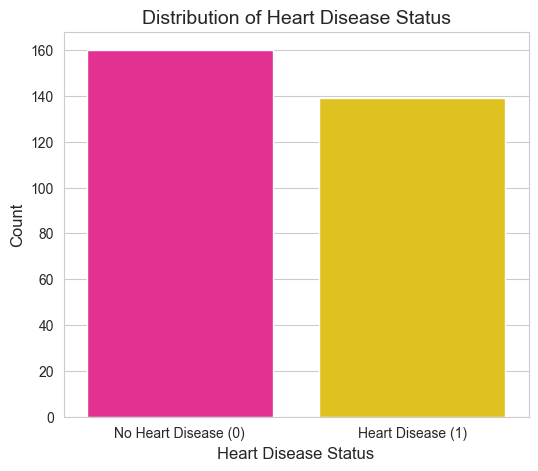

In [5]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="target", palette=palette)
plt.title("Distribution of Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Count")
plt.xticks([0,1], ["No Heart Disease (0)", "Heart Disease (1)"])
plt.show()

**Explanation of the visualization:**  
This bar chart shows the number of patients with and without heart disease. It helps determine whether the dataset is balanced between the two outcome groups.

### Age

**Explanation of the variable:**  
Age represents the patient’s age in years. It is a continuous variable used to examine whether heart disease becomes more common at older ages.

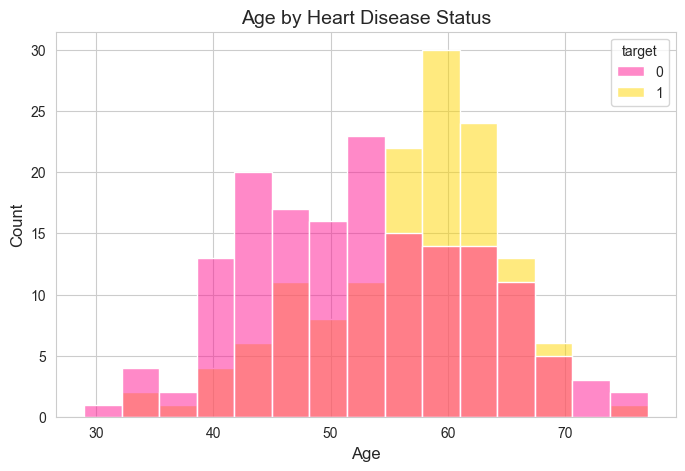

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", hue="target", bins=15, kde=False, palette=palette)
plt.title("Age by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

**Explanation of the visualization:**  
This histogram compares the age distribution of patients with and without heart disease. It helps show whether heart disease appears more often in certain age ranges.

### Sex

**Explanation of the variable:**  
Sex identifies the biological sex of the patient. In this dataset, 0 = female and 1 = male.

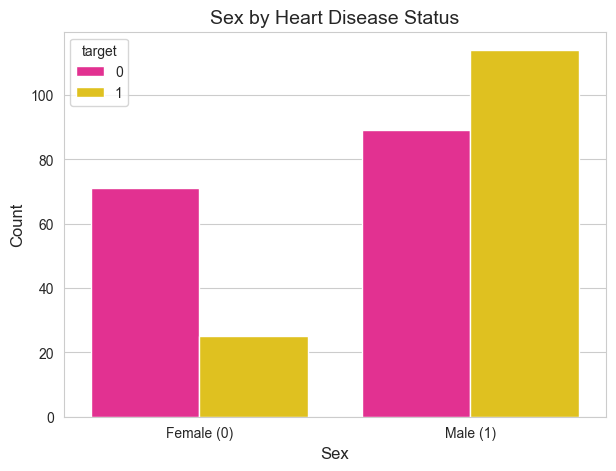

In [7]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="sex", hue="target", palette=palette)
plt.title("Sex by Heart Disease Status")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks([0,1], ["Female (0)", "Male (1)"])
plt.show()

**Explanation of the visualization:**  
This grouped bar chart compares males and females by heart disease status. It helps show whether heart disease appears more common in one sex within this dataset.

### Chest Pain Type

**Explanation of the variable:**  
Chest pain type describes the kind of chest pain experienced by the patient. It is coded as 0 = typical angina, 1 = atypical angina, 2 = non-anginal pain, and 3 = asymptomatic.

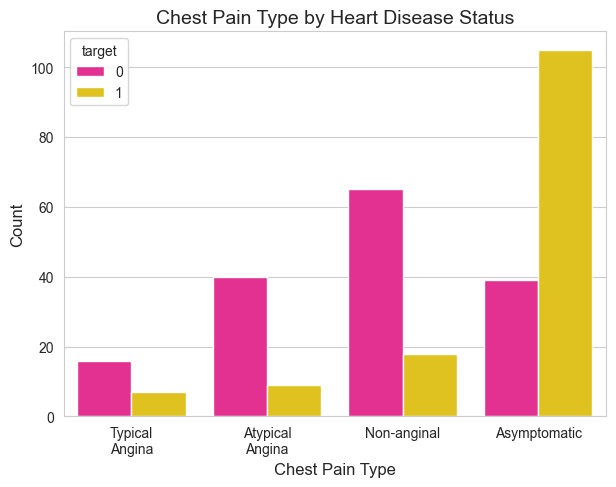

In [8]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="cp", hue="target", palette=palette)
plt.title("Chest Pain Type by Heart Disease Status")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.xticks([0,1,2,3], ["Typical\nAngina", "Atypical\nAngina", "Non-anginal", "Asymptomatic"])
plt.show()

**Explanation of the visualization:**  
This grouped bar chart shows how each chest pain type is distributed across patients with and without heart disease. It helps identify whether certain chest pain categories appear more often among patients with heart disease.

### Resting Blood Pressure

**Explanation of the variable:**  
Resting blood pressure measures the patient’s blood pressure while at rest, in millimeters of mercury (mm Hg). It is a continuous variable and is important because high blood pressure is a common cardiovascular risk factor.

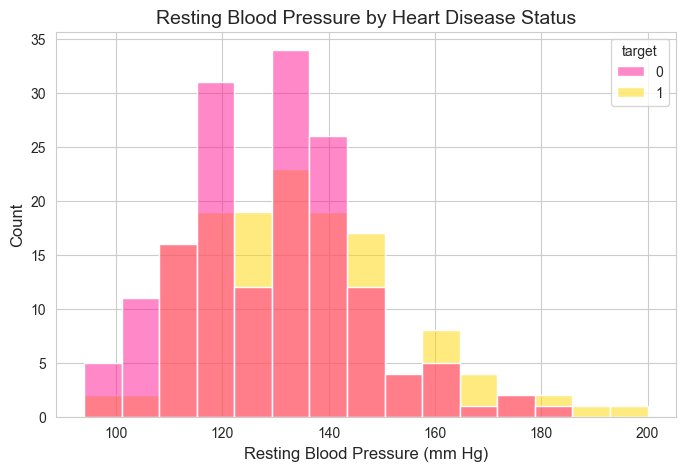

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="trestbps", hue="target", bins=15, kde=False, palette=palette)
plt.title("Resting Blood Pressure by Heart Disease Status")
plt.xlabel("Resting Blood Pressure (mm Hg)")
plt.ylabel("Count")
plt.show()

**Explanation of the visualization:**  
This histogram compares resting blood pressure values for patients with and without heart disease. It helps show whether higher resting blood pressure values are more common in either group.

### Cholesterol

**Explanation of the variable:**  
Cholesterol measures the patient’s serum cholesterol level in milligrams per deciliter (mg/dL). It is a continuous variable related to cardiovascular health.

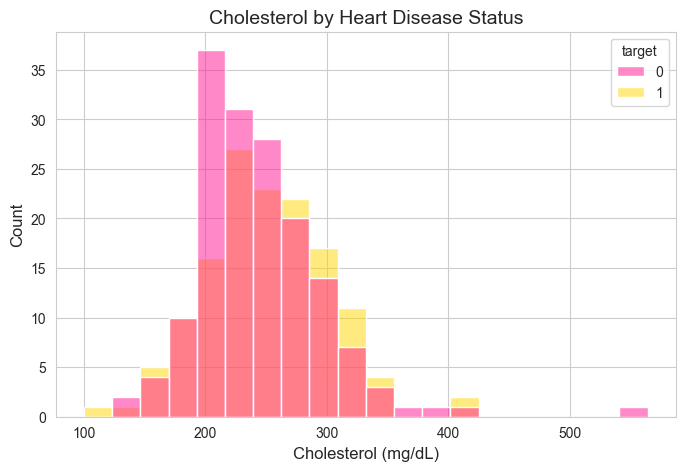

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="chol", hue="target", bins=20, kde=False, palette=palette)
plt.title("Cholesterol by Heart Disease Status")
plt.xlabel("Cholesterol (mg/dL)")
plt.ylabel("Count")
plt.show()

**Explanation of the visualization:**  
This histogram compares cholesterol levels across heart disease groups. It helps show whether patients with heart disease tend to have different cholesterol patterns than patients without heart disease.

### Fasting Blood Sugar

**Explanation of the variable:**  
Fasting blood sugar shows whether the patient’s fasting blood sugar is greater than 120 mg/dL. In this dataset, 0 = false and 1 = true.

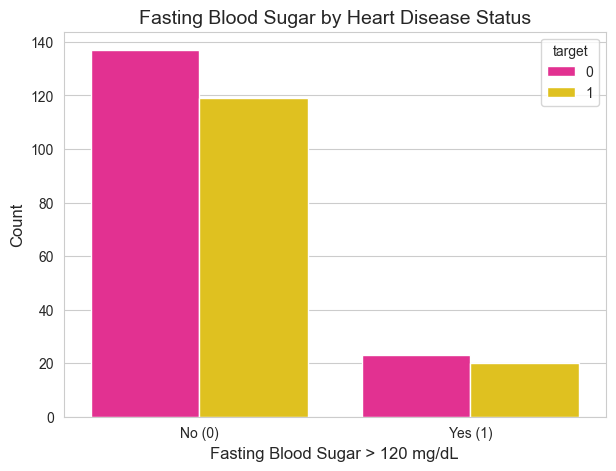

In [11]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="fbs", hue="target", palette=palette)
plt.title("Fasting Blood Sugar by Heart Disease Status")
plt.xlabel("Fasting Blood Sugar > 120 mg/dL")
plt.ylabel("Count")
plt.xticks([0,1], ["No (0)", "Yes (1)"])
plt.show()

**Explanation of the visualization:**  
This grouped bar chart compares patients with and without elevated fasting blood sugar by heart disease status. It helps show whether high fasting blood sugar appears more often in the heart disease group.

### Resting ECG

**Explanation of the variable:**  
Resting ECG records the patient’s resting electrocardiographic results. It is coded as 0 = normal, 1 = ST-T abnormality, and 2 = left ventricular hypertrophy.

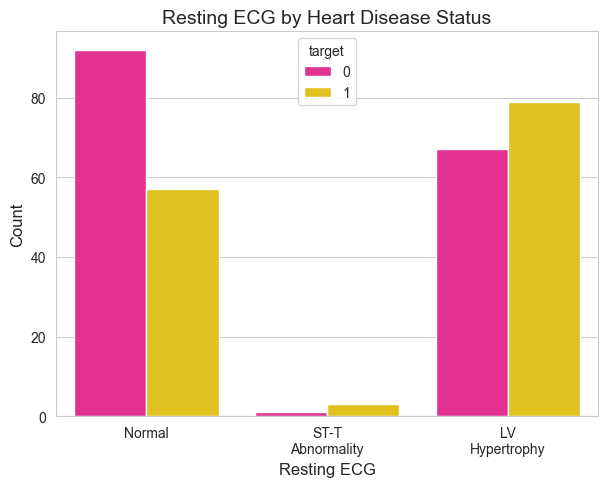

In [12]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="restecg", hue="target", palette=palette)
plt.title("Resting ECG by Heart Disease Status")
plt.xlabel("Resting ECG")
plt.ylabel("Count")
plt.xticks([0,1,2], ["Normal", "ST-T\nAbnormality", "LV\nHypertrophy"])
plt.show()

**Explanation of the visualization:**  
This grouped bar chart shows resting ECG categories by heart disease status. It helps identify whether certain ECG results appear more often among patients with heart disease.

### Maximum Heart Rate Achieved

**Explanation of the variable:**  
Maximum heart rate achieved records the highest heart rate reached by the patient during testing. It is a continuous variable that can help describe cardiovascular performance.

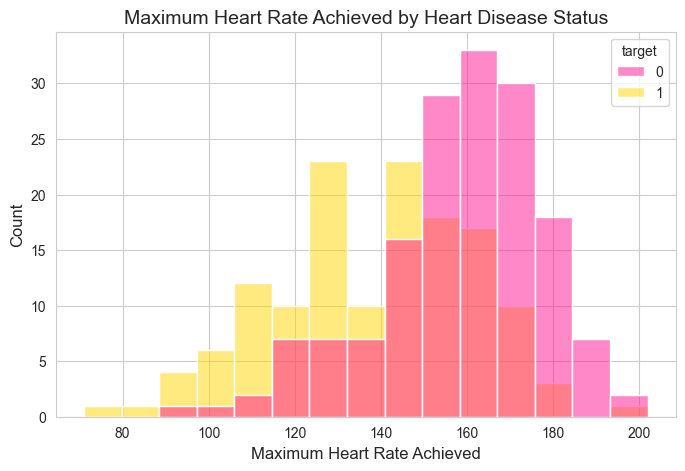

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="thalach", hue="target", bins=15, kde=False, palette=palette)
plt.title("Maximum Heart Rate Achieved by Heart Disease Status")
plt.xlabel("Maximum Heart Rate Achieved")
plt.ylabel("Count")
plt.show()

**Explanation of the visualization:**  
This histogram compares maximum heart rate values between patients with and without heart disease. It helps show whether one group tends to reach higher or lower heart rates during testing.

### Exercise Induced Angina

**Explanation of the variable:**  
Exercise induced angina indicates whether the patient experienced chest pain during exercise. In this dataset, 0 = no and 1 = yes.

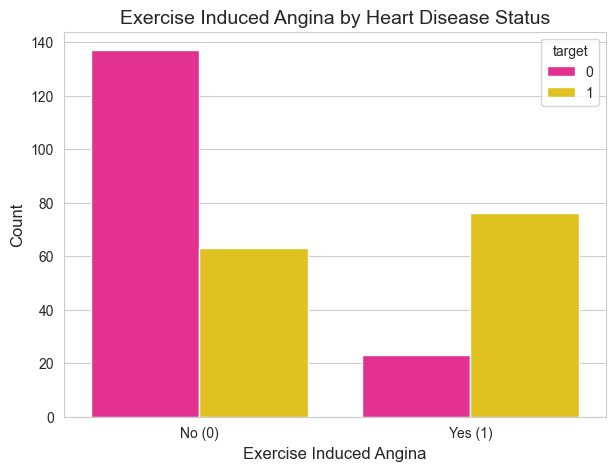

In [14]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="exang", hue="target", palette=palette)
plt.title("Exercise Induced Angina by Heart Disease Status")
plt.xlabel("Exercise Induced Angina")
plt.ylabel("Count")
plt.xticks([0,1], ["No (0)", "Yes (1)"])
plt.show()

**Explanation of the visualization:**  
This grouped bar chart compares exercise induced angina across heart disease groups. It helps show whether patients who experienced angina during exercise were more likely to have heart disease.

### ST Depression

**Explanation of the variable:**  
Oldpeak measures ST depression induced by exercise relative to rest. It is a continuous variable related to stress-related heart activity.

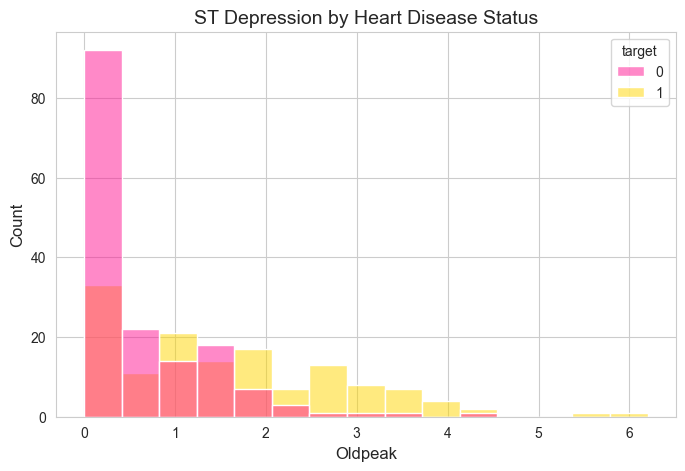

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="oldpeak", hue="target", bins=15, kde=False, palette=palette)
plt.title("ST Depression by Heart Disease Status")
plt.xlabel("Oldpeak")
plt.ylabel("Count")
plt.show()

**Explanation of the visualization:**  
This histogram compares ST depression values between the two heart disease groups. It helps show whether higher oldpeak values appear more often among patients with heart disease.

### Slope

**Explanation of the variable:**  
Slope refers to the slope of the peak exercise ST segment. It is coded as 0 = upsloping, 1 = flat, and 2 = downsloping.

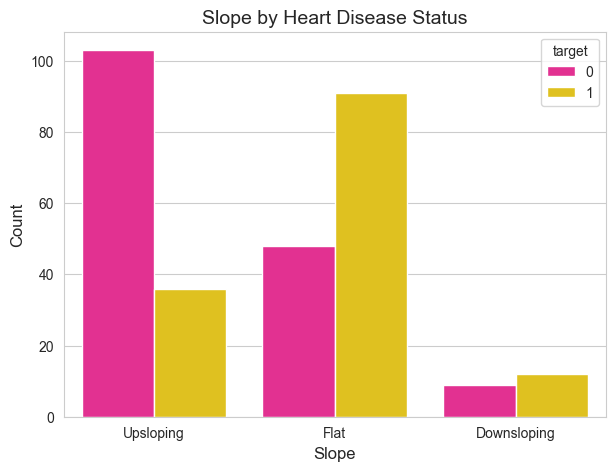

In [16]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="slope", hue="target", palette=palette)
plt.title("Slope by Heart Disease Status")
plt.xlabel("Slope")
plt.ylabel("Count")
plt.xticks([0,1,2], ["Upsloping", "Flat", "Downsloping"])
plt.show()

**Explanation of the visualization:**  
This grouped bar chart compares slope categories for patients with and without heart disease. It helps show whether certain ST segment slope patterns are more common in one heart disease group.

### Number of Major Vessels

**Explanation of the variable:**  
The variable ca records the number of major vessels colored by fluoroscopy. It is a discrete numerical variable that may provide information about the patient’s cardiovascular condition.

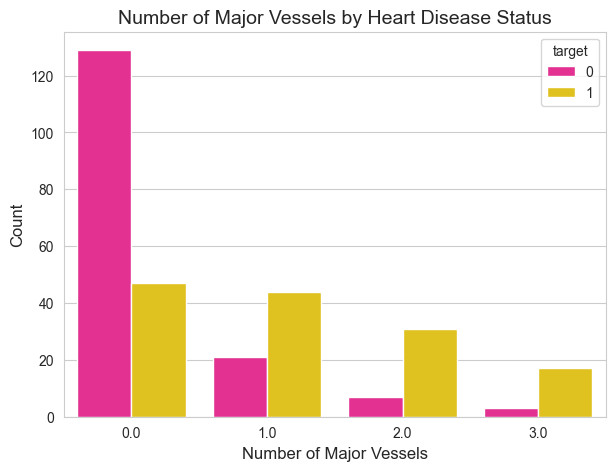

In [17]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="ca", hue="target", palette=palette)
plt.title("Number of Major Vessels by Heart Disease Status")
plt.xlabel("Number of Major Vessels")
plt.ylabel("Count")
plt.show()

**Explanation of the visualization:**  
This grouped bar chart shows the number of major vessels for patients with and without heart disease. It helps reveal whether lower or higher vessel counts are more common in either group.

### Thalassemia

**Explanation of the variable:**  
Thal is a categorical variable related to thalassemia test results. It is coded as 1 = normal, 2 = fixed defect, and 3 = reversable defect.

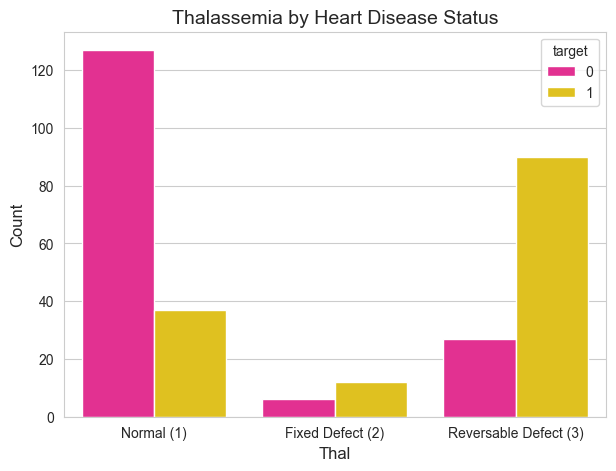

In [18]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="thal", hue="target", palette=palette)
plt.title("Thalassemia by Heart Disease Status")
plt.xlabel("Thal")
plt.ylabel("Count")
plt.xticks([0,1,2], ["Normal (1)", "Fixed Defect (2)", "Reversable Defect (3)"])
plt.show()

**Explanation of the visualization:**  
This grouped bar chart compares thal categories across heart disease groups. It helps show whether certain thal results appear more frequently among patients with heart disease.

### Correlation Heatmap

**Explanation of the visualization:**  
This heatmap shows the correlation between numerical variables in the dataset. Correlation values closer to 1 mean a stronger positive relationship, values closer to -1 mean a stronger negative relationship, and values near 0 mean little to no linear relationship.

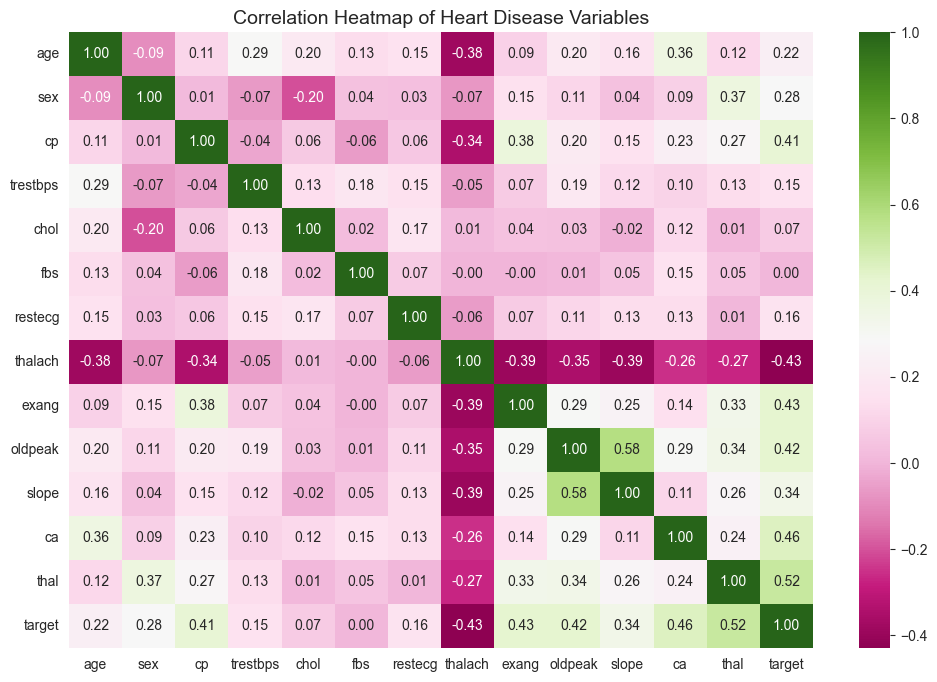

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="PiYG", fmt=".2f")
plt.title("Correlation Heatmap of Heart Disease Variables")
plt.show()

**Explanation of the visualization:**  
This heatmap helps identify which variables have stronger relationships with the target variable. Variables with larger positive or negative correlations with target may be more useful when studying or predicting heart disease.

## Predictive Modeling

In addition to descriptive analysis, a logistic regression model was used to examine how well the variables predict heart disease. Model performance was evaluated using a confusion matrix.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Define X (features) and y (target)
X = df.drop(columns=["target"])
y = df["target"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

/Users/hanaaglan/Desktop/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


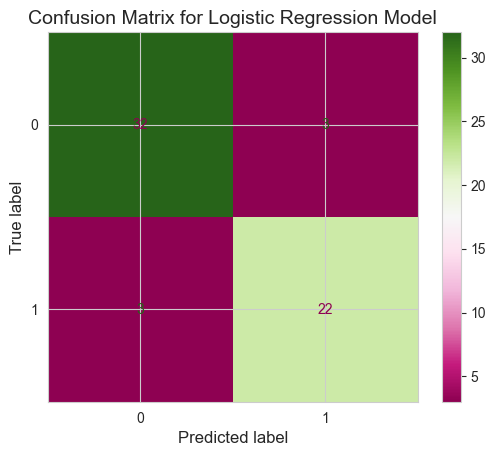

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="PiYG")

plt.title("Confusion Matrix for Logistic Regression Model")
plt.show()

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy, 3))

Model Accuracy: 0.9


**Explanation of the Model Results:**  
The logistic regression model was used to predict whether a patient has heart disease based on the available variables. The confusion matrix shows how many predictions were correct and incorrect. The diagonal values represent correct predictions, while the off-diagonal values represent errors.

The model accuracy provides a summary measure of how well the model performs overall. A higher accuracy indicates better predictive performance. This model helps demonstrate that the variables in the dataset contain useful information for predicting heart disease.

## Discussion

The results of this analysis show that several variables appear to differ between patients with and without heart disease. In particular, variables such as chest pain type, exercise-induced angina, maximum heart rate achieved, ST depression (oldpeak), slope, number of major vessels, and thalassemia show clear visual differences between the two groups. Patients with heart disease tend to appear more frequently in specific chest pain categories (especially asymptomatic), are more likely to experience exercise-induced angina, and often show higher ST depression values. Additionally, differences in maximum heart rate and diagnostic indicators such as slope and number of vessels suggest variation in cardiovascular function between groups. These findings support the initial hypothesis that clinical and diagnostic variables would show noticeable differences between patients with and without heart disease. 

In addition to the descriptive findings, the logistic regression model further supports this conclusion. The model was able to predict heart disease status with a reasonable level of accuracy, as shown by the confusion matrix and overall accuracy score. The confusion matrix demonstrated that a substantial number of patients were correctly classified, particularly along the diagonal (true positives and true negatives), indicating that the variables included in the dataset contain meaningful predictive information. While some misclassification occurred, which is expected in real-world data, the model results reinforce the idea that these variables are not only visually different between groups but also statistically useful for prediction.

These findings are generally consistent with existing research discussed in the introduction. Previous research from the Centers for Disease Control and Prevention and the World Health Organization identifies factors such as age, cholesterol, and blood pressure as important contributors to heart disease risk [1][3]. While this study does show some differences in age and cholesterol distributions, the strongest visible differences in this dataset are related to clinical and diagnostic variables, such as chest pain type and exercise-related measures. This aligns with the understanding that symptoms and diagnostic test results often provide more immediate indicators of heart disease presence. However, the relative lack of strong visual separation in some traditional risk factors, such as cholesterol, may differ from broader population-level findings. This discrepancy could be due to the specific sample used in the dataset, differences in patient selection, or the fact that the dataset is more focused on patients already undergoing clinical evaluation rather than a general population sample.

The public health implications of these findings are important. Understanding which variables are most visibly associated with heart disease can help improve screening and early detection efforts. For example, recognizing that certain types of chest pain and exercise-related symptoms are strongly associated with heart disease can help healthcare providers prioritize patients for further testing. Additionally, identifying patterns in diagnostic variables such as ST depression and slope may support more accurate interpretation of stress tests and other clinical assessments. From a broader perspective, these findings reinforce the importance of combining both demographic risk factors and clinical indicators when assessing cardiovascular health. Public health strategies that integrate both prevention (targeting risk factors like blood pressure and cholesterol) and early detection (through symptom recognition and testing) are likely to be most effective. The addition of predictive modeling also highlights how data-driven approaches can support decision-making in healthcare by identifying patients who may be at higher risk.

This study has several limitations that should be considered when interpreting the results. First, the dataset is observational and cross-sectional, meaning that it cannot establish causal relationships between variables and heart disease. Second, missing values were removed during the data cleaning process, which may reduce the sample size and introduce bias if the missing data were not randomly distributed. Third, the dataset may not be representative of the general population, as it is derived from patients who were likely already being evaluated for heart disease, which could limit the generalizability of the findings. Additionally, some variables were converted from categorical text into numerical form, which may introduce simplification or loss of detail. The logistic regression model itself also has limitations, as it assumes linear relationships between predictors and the log-odds of the outcome and may not capture more complex interactions between variables. Finally, while the model achieved reasonable accuracy, misclassifications indicate that additional variables or more advanced models may be needed to improve prediction. Despite these limitations, the study provides useful insights into how key variables are associated with heart disease within this dataset.

## Conclusion

This project analyzed a public heart disease dataset to explore how patient characteristics differ by heart disease status. The results suggest that several clinical variables show visible differences between patients with and without heart disease. These patterns are important because they may help identify potential risk factors and guide future public health research. Future studies could use statistical testing or machine learning models to evaluate which variables are strongest predictors of heart disease.

## References

1. Centers for Disease Control and Prevention. Heart disease facts [Internet]. CDC; 2024 [cited 2026 Apr 27]. Available from: https://www.cdc.gov/heart-disease/data-research/facts-stats/index.html

2. Janosi A, Steinbrunn W, Pfisterer M, Detrano R. Heart Disease Data Set [Internet]. UCI Machine Learning Repository; 1988 [cited 2026 Apr 27]. Available from: https://archive.ics.uci.edu/dataset/45/heart+disease

3. World Health Organization. Cardiovascular diseases [Internet]. WHO; 2024 [cited 2026 Apr 27]. Available from: https://www.who.int/health-topics/cardiovascular-diseases